In [10]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # adds project root to path

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, multilabel_confusion_matrix

from src.data.load_data import load_test_data, load_test_labels
from src.data.preprocess import preprocess_test
from predict import predict, predict_proba

# Load test data
test = load_test_data()
test_labels = load_test_labels()
test, test_labels = preprocess_test(test, test_labels)

y_true = test_labels.drop(columns=["id"]).values
y_pred = predict(test["comment_text"]).values
y_proba = predict_proba(test["comment_text"])

LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
MODELS = {"TF-IDF + LR": (y_pred, y_proba)}  # add more models here later

📦 Model loaded from /home/vahe/bin/toxic-comment-classifier/saved_models/baseline_model.pkl
📦 Model loaded from /home/vahe/bin/toxic-comment-classifier/saved_models/baseline_model.pkl


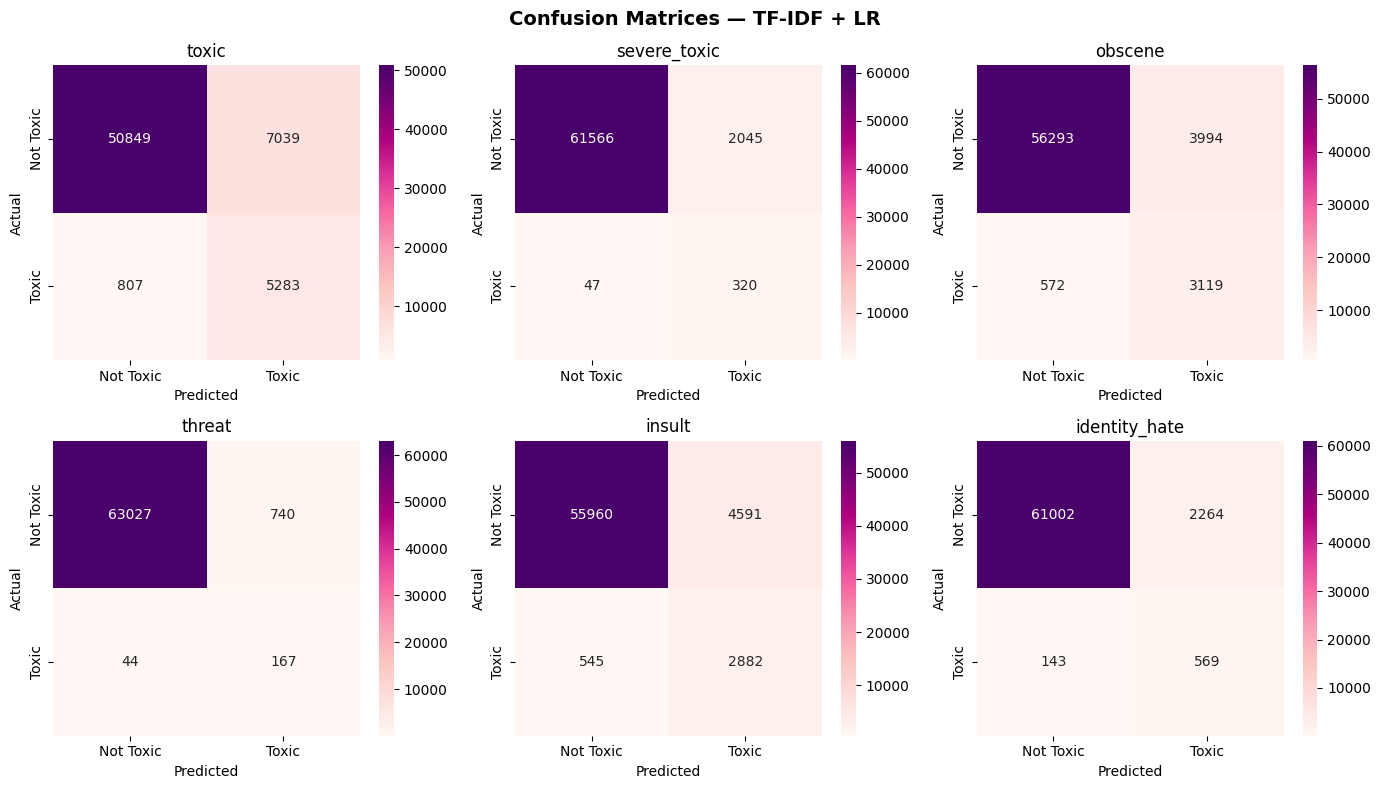

In [11]:
def plot_confusion_matrices(y_true, y_pred, labels, model_name):
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, (cm, label) in enumerate(zip(mcm, labels)):
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Not Toxic', 'Toxic'],
            yticklabels=['Not Toxic', 'Toxic'],
            ax=axes[i]
        )
        axes[i].set_title(f'{label}')
        axes[i].set_ylabel('Actual')
        axes[i].set_xlabel('Predicted')

    fig.suptitle(f'Confusion Matrices — {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

for model_name, (y_pred_m, _) in MODELS.items():
    plot_confusion_matrices(y_true, y_pred_m, LABELS, model_name)

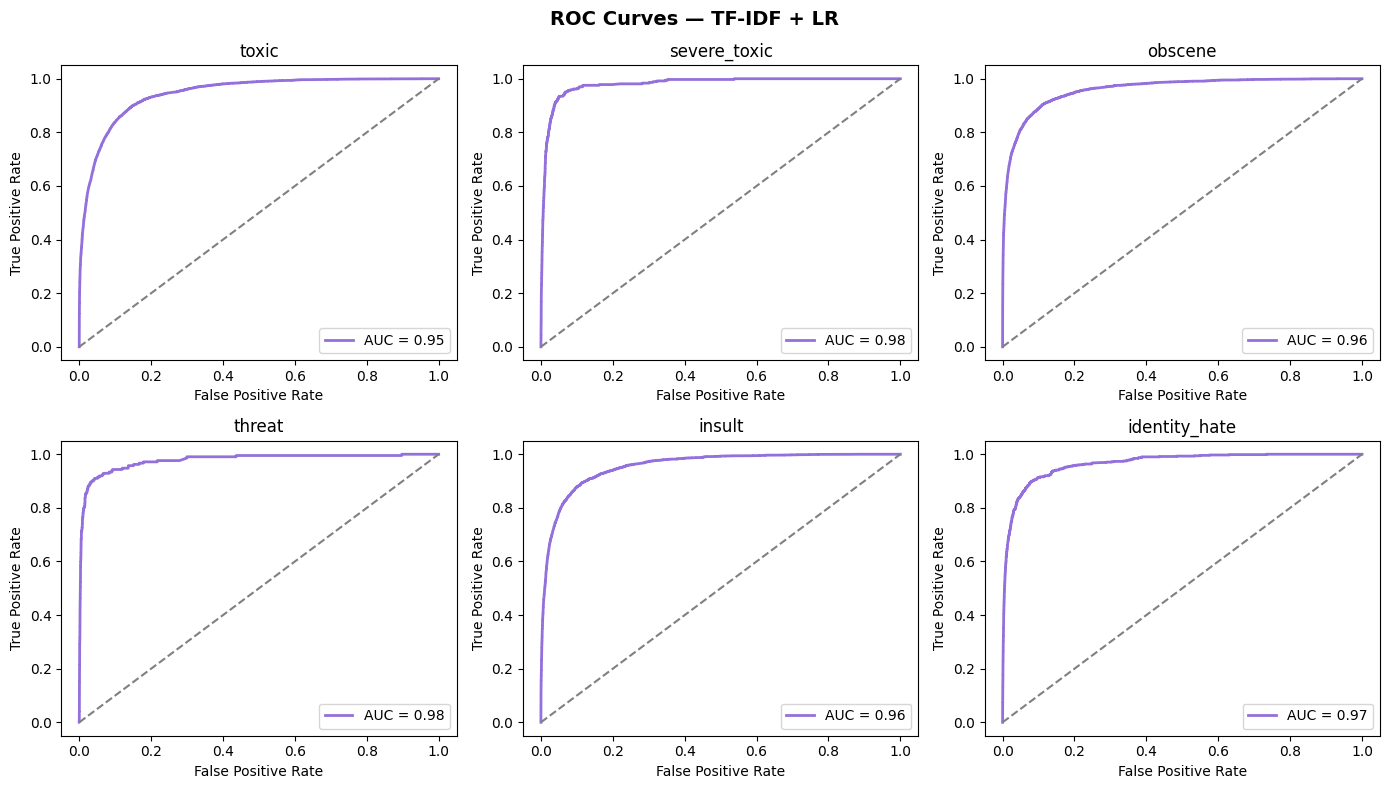

In [12]:
def plot_roc_curves(y_true, y_proba, labels, model_name):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, label in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)

        axes[i].plot(fpr, tpr, color='mediumpurple', lw=2, label=f'AUC = {roc_auc:.2f}')
        axes[i].plot([0, 1], [0, 1], color='gray', linestyle='--')
        axes[i].set_title(f'{label}')
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].legend(loc='lower right')

    fig.suptitle(f'ROC Curves — {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

for model_name, (_, y_proba_m) in MODELS.items():
    plot_roc_curves(y_true, y_proba_m, LABELS, model_name)

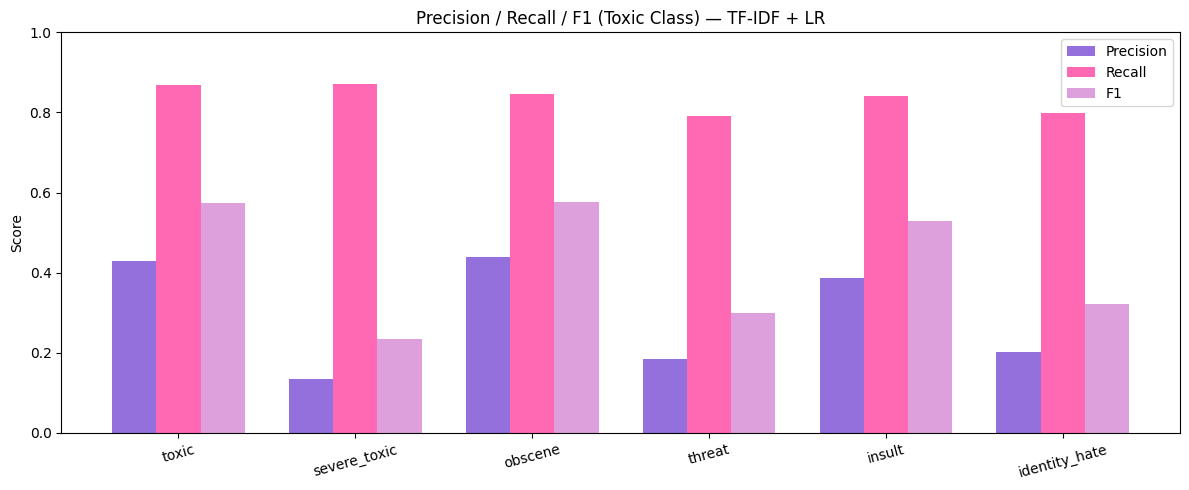

In [13]:
from sklearn.metrics import classification_report
import pandas as pd

def plot_precision_recall_f1(y_true, y_pred, labels, model_name):
    rows = []
    for i, label in enumerate(labels):
        report = classification_report(
            y_true[:, i], y_pred[:, i],
            output_dict=True, zero_division=0
        )
        rows.append({
            "label":     label,
            "precision": report["1"]["precision"],  # toxic class
            "recall":    report["1"]["recall"],      # toxic class
            "f1":        report["1"]["f1-score"]     # toxic class
        })

    df_report = pd.DataFrame(rows).set_index("label")

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(labels))
    width = 0.25

    ax.bar(x - width, df_report["precision"], width, label="Precision", color="mediumpurple")
    ax.bar(x,         df_report["recall"],    width, label="Recall",    color="hotpink")
    ax.bar(x + width, df_report["f1"],        width, label="F1",        color="plum")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(f"Precision / Recall / F1 (Toxic Class) — {model_name}")
    ax.legend()
    plt.tight_layout()
    plt.show()

for model_name, (y_pred_m, _) in MODELS.items():
    plot_precision_recall_f1(y_true, y_pred_m, LABELS, model_name)